In [ ]:
!pip install pandas numpy scikit-learn nltk google-play-scraper Sastrawi matplotlib seaborn wordcloud tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from google_play_scraper import reviews_all, Sort
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm import tqdm

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
def ambil_ulasan_wuwa():
    hasil = reviews_all(
        'com.kurogame.wutheringwaves.global',
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT
    )
    df = pd.DataFrame(hasil)
    return df[['content', 'score']]


ulasan_df = ambil_ulasan_wuwa()


ulasan_df = ulasan_df.sample(1000, random_state=42)
print("Jumlah data yang berhasil diambil:", len(ulasan_df))

Jumlah data yang berhasil diambil: 1000


In [ ]:
import nltk
nltk.download('punkt_tab')
def label_sentimen(rating):
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

ulasan_df['sentimen'] = ulasan_df['score'].apply(label_sentimen)

def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'\d+', '', text) # Hapus Angka
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^\w\s]', '', text)
    return text

ulasan_df['content'] = ulasan_df['content'].fillna('')
ulasan_df['cleaning'] = ulasan_df['content'].apply(cleaning)


ulasan_df['case_folding'] = ulasan_df['cleaning'].str.lower()


ulasan_df['tokenisasi'] = ulasan_df['case_folding'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
normal_dict = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "gabisa": "tidak bisa",
    "bgt": "banget", "apk": "aplikasi", "yg": "yang", "aja": "saja",
    "udah": "sudah", "kalo": "kalau", "dev": "developer", "patah": "lag",
    "fps": "frame rate", "drop": "turun", "pake": "pakai"
}

def normalize(tokens):
    return [normal_dict[word] if word in normal_dict else word for word in tokens]

ulasan_df['normalisasi'] = ulasan_df['tokenisasi'].apply(normalize)

In [ ]:
factory_stop = StopWordRemoverFactory()
stopwords = set(factory_stop.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

ulasan_df['stopword_removed'] = ulasan_df['normalisasi'].apply(remove_stopwords)

In [ ]:
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

def stemming_text(tokens):
    text = " ".join(tokens)
    return stemmer.stem(text)

tqdm.pandas()
ulasan_df['stemming'] = ulasan_df['stopword_removed'].progress_apply(stemming_text)
ulasan_df['final_text'] = ulasan_df['stemming']

100%|██████████| 1000/1000 [03:30<00:00,  4.75it/s]


In [ ]:
ulasan_df['final_text'] = ulasan_df['stemming']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(ulasan_df['final_text']).toarray()
y = ulasan_df['sentimen']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model = ComplementNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("🔥 AKURASI MODEL:", accuracy_score(y_test, y_pred))
print("\n📊 LAPORAN KLASIFIKASI:\n", classification_report(y_test, y_pred))

🔥 AKURASI MODEL: 0.77

📊 LAPORAN KLASIFIKASI:
               precision    recall  f1-score   support

     negatif       0.51      0.58      0.55        31
      netral       0.00      0.00      0.00        12
     positif       0.89      0.87      0.88       157

    accuracy                           0.77       200
   macro avg       0.47      0.48      0.48       200
weighted avg       0.78      0.77      0.78       200



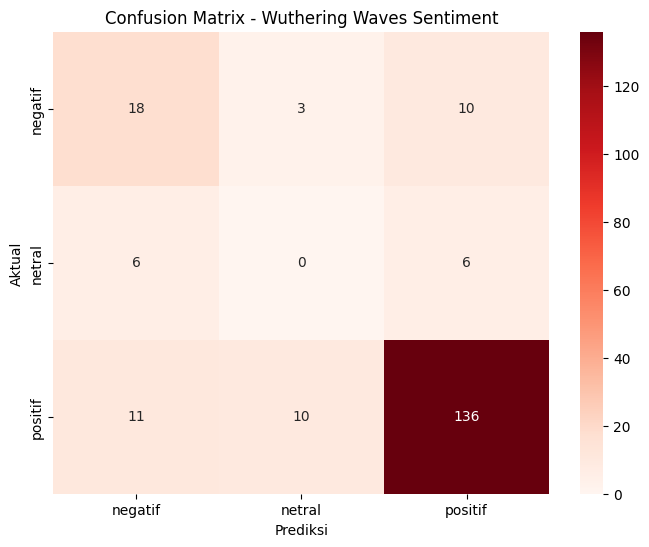

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds',
            xticklabels=['negatif', 'netral', 'positif'], yticklabels=['negatif', 'netral', 'positif'])
plt.title("Confusion Matrix - Wuthering Waves Sentiment")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

/tmp/ipykernel_742/2366578762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ulasan_df, x='sentimen', palette='viridis')


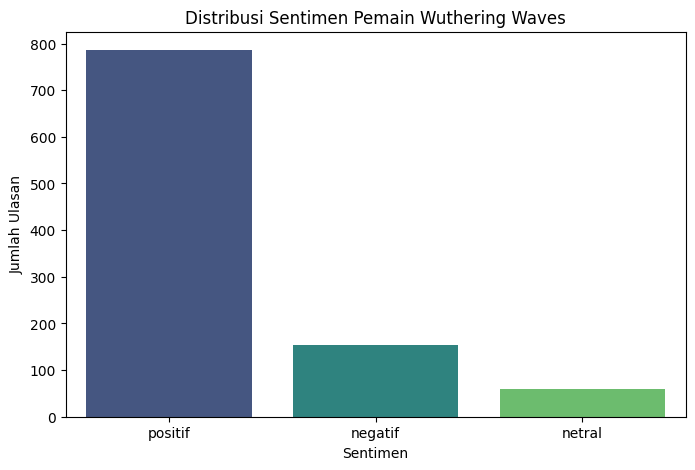

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=ulasan_df, x='sentimen', palette='viridis')
plt.title("Distribusi Sentimen Pemain Wuthering Waves")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

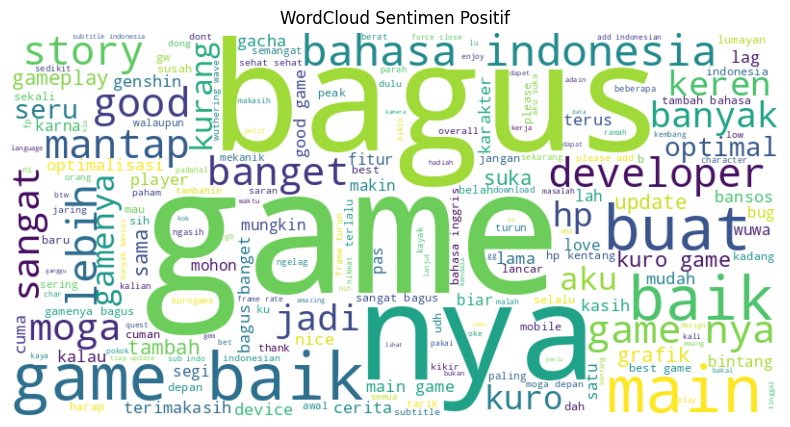

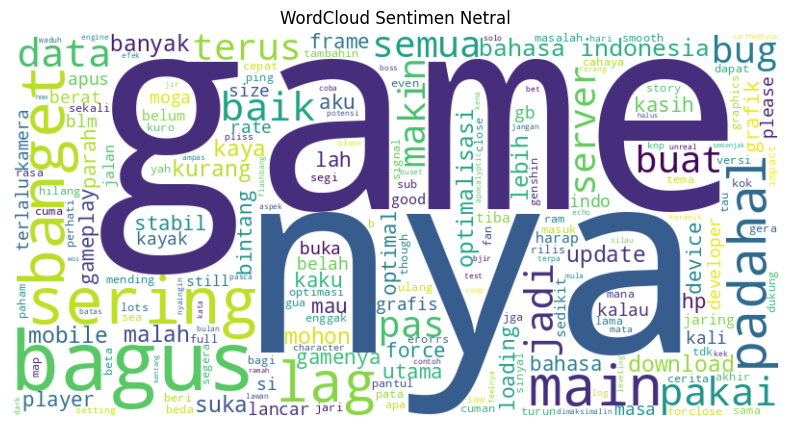

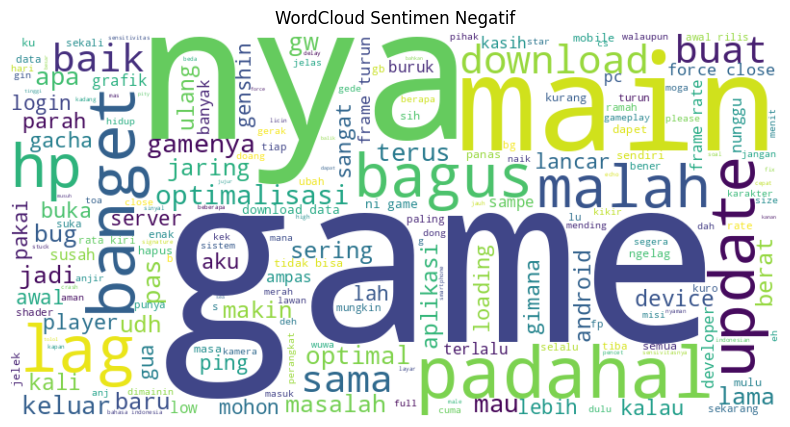

In [ ]:
for sentimen_tipe in ['positif', 'netral', 'negatif']:
    text = ' '.join(ulasan_df[ulasan_df['sentimen'] == sentimen_tipe]['final_text'])
    if text.strip():
        wc = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'WordCloud Sentimen {sentimen_tipe.capitalize()}')
        plt.show()